In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

# device = jax.local_devices()[0]
# print(device.device_kind)

# stats = device.memory_stats()
# free = stats["bytes_limit"] - stats["bytes_in_use"]
# print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
# print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
# print(f"Free       : {free / 1024**3:.2f} GB")

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

ERROR:2026-06-11 01:03:54,142:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dgxuser/max/conda/envs/retrain/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo version: 0.0.10
dorito version: 0.2.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname
from retrain_fns import Tee

print(f"host name: {gethostname()}")

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/outputs/retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.10"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False


# Quick toggle flags
epochs = 100
all_data_flag = False
one_filt_flag = True
binary_flag = False
val_flag = False
plot_flag = check_script()
save_flag = check_script()

if save_flag:
    try:
        job_index = int(sys.argv[1])
    except:
        pass
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None

print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-cpu-0-5
Running in a notebook or interactive shell
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.10


In [3]:
from retrain_fns import summarise_files

# Add extra bad pixels
badpix = np.load(f"{cache_dir}/full_badpix.npy")
badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    return file


## Validation files
Calibrators from other science programs

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

val_files = []

# Collated validator subset
program_path = os.path.join(data_dir, "VAL_SUBSET/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
val_files += files

# Creating a subset of the data for testing
if not all_data_flag:
    _ = []
    filts = []
    for file in val_files:
        filt = file[0].header["FILTER"]
        if one_filt_flag:
            if filt != "F480M":
                continue
        if filt not in filts:
            _.append(file)
            filts.append(filt)
    val_files = _

# Adding bad pixels and summarising metadata
val_files = [add_badpix(file) for file in val_files]
summarise_files(val_files)

  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M    1/1  9/65  05-06-2022  Thatte, Deepashri  True


## Calibration files
The main training data, including flats.

In [5]:
calpsf_files = []
calbin_files = []

print("CAL4481 - Anand Sivaramakrishnan")
program_path = os.path.join(data_dir, "4481/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
calpsf_files += files

print()
print("CAL8330 - Benjamin Pope")
program_path = os.path.join(data_dir, "8330/calslope/")
files = get_files(program_path, "nis_calslope")
calbin_files += files
calbin_files = [file for file in calbin_files if file[0].header["NGROUPS"] > 3]

# Creating a subset of the data for testing

if not all_data_flag:
    _ = []
    filts = []
    for file in calpsf_files:
        filt = file[0].header["FILTER"]
        if one_filt_flag:
            if filt != "F480M":
                continue
        if filt not in filts:
            _.append(file)
            filts.append(filt)
    calpsf_files = _

    _ = []
    filts = []
    for file in calbin_files:
        filt = file[0].header["FILTER"]
        if one_filt_flag:
            if filt != "F480M":
                continue
        if filt not in filts:
            _.append(file)
            filts.append(filt)
    calbin_files = _

calpsf_files = [add_badpix(file) for file in calpsf_files]
summarise_files(calpsf_files)

calbin_files = [add_badpix(file) for file in calbin_files[0:15]]
# calbin_files = [add_badpix(file) for file in calbin_files]
summarise_files(calbin_files)

CAL4481 - Anand Sivaramakrishnan

CAL8330 - Benjamin Pope
  program    target filter dither     g/i        date                       PI   CAL
0    4481  HD-41094  F480M    4/5  30/760  05-05-2024  Sivaramakrishnan, Anand  True
  program    target filter dither     g/i        date              PI    CAL
0    8330  V-EZ-Aqr  F480M   9/10  18/220  11-11-2025  Pope, Benjamin  False


Flats.

In [6]:
flat_files = []
print()
print("FLATS")
program_path = os.path.join(data_dir, "FLATS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_LAMP")
flat_files += files
# flat_files = [file for file in flat_files if file[0].header["NGROUPS"] != 45]

# Creating a subset of the data for testing
if not all_data_flag:
    if one_filt_flag:
        flat_files = flat_files[0:1]
    else:
        flat_files = flat_files[1:4]

flat_files = [add_badpix(file) for file in flat_files]
summarise_files(flat_files)


FLATS
  program   target filter dither    g/i        date             PI   CAL
0    1503  UNKNOWN  CLEAR    1/1  20/33  10-02-2023  Martel, Andre  FLAT


In [7]:
# dark_files = []
# print()
# print("DARKS")
# program_path = os.path.join(data_dir, "DARKS/calslope/")
# files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_DARK")
# dark_files += files

# # Creating a subset of the data for testing
# if not all_data_flag:
#     if one_filt_flag:
#         dark_files = dark_files[0:1]

# dark_files = [add_badpix(file) for file in dark_files]
# summarise_files(dark_files)

# Exposures

In [8]:
from amigo.model_fits import PointFit, FlatFit
from retrain_fns import BinaryFit, DarkFit

# Construct the exposures
calpsf_exposures = [PointFit(file) for file in calpsf_files]
calbin_exposures = [BinaryFit(file) for file in calbin_files]
val_exposures = [PointFit(file) for file in val_files]
flat_exposures = [FlatFit(file) for file in flat_files]
# dark_exposures = [DarkFit(file) for file in dark_files]

if binary_flag:
    cal_exposures = calbin_exposures + calpsf_exposures
else:
    cal_exposures = calpsf_exposures

if val_flag:
    exposures = cal_exposures + flat_exposures + val_exposures
else:
    exposures = cal_exposures + flat_exposures

print(f"Total number of exposures: {len(exposures)}")

# just closing the files
files = calpsf_files + calbin_files + val_files + flat_files# + dark_files
_ = [f.close() for f in files]

Total number of exposures: 2


Finally, let's batch the exposures for training.

In [9]:
from amigo.fitting import batch_exposures

bs = 1 if one_filt_flag else 3

# Get the batches: Calibrator, flats, and validators
cal_batch = batch_exposures(cal_exposures, batch_size=bs, key="cal")
flat_batch = batch_exposures(flat_exposures, batch_size=bs, key="flat")
val_batch = batch_exposures(val_exposures, batch_size=bs, key="val")
# dark_batch = batch_exposures(dark_exposures, batch_size=bs, key="dark")
batches = {**cal_batch, **flat_batch}

# Building model

In [10]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# Get the model
model = AmigoModel(
    exposures=exposures,
    # optics=AMIOptics(),
    optics=AMIOptics(static=False),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)

Populate from state.

In [11]:
state = load_dict(amigo_files_path + "/calibration.npy")
best_state = state
# best_state = load_dict(amigo_files_path + "/best_state.npy")
if "jitter" in state.keys():
    state["sigma"] = state["jitter"]
# state = load_dict(amigo_files_path + "/calibration.npy")
print(state.keys())

for key, value in best_state.items():
    if key not in [
        'FF',
        'non_linearity',
        'dark_current',
        'distortion',
        'defocus',
        'nn_weights',
        # 'aberrations',
        'sigma',
    ]:
        continue
    model = model.set(key, value)

ab_dict = {}
for key, _ in model.aberrations.items():
    prog, filt = key.split("_")
    ab_dict[key] = state["aberrations"][filt]

model = model.set("aberrations", ab_dict)


# initial normalisations
ff = model.FF
ff -= np.median(ff) - 1.0
ff = ff.at[badpix].set(1.0)
model = model.set("FF", ff)

non_lin = model.non_linearity.at[:, badpix].set(0)
model = model.set("non_linearity", non_lin)

if binary_flag:
    for exp in calbin_exposures:
        model = model.set(
            exp.map_param("pas"),
            np.array(147.),
        )
        model = model.set(
            exp.map_param("separations"),
            np.array(0.123),
        )
        model = model.set(
            exp.map_param("contrasts"),
            np.array(0.376),
        )

dict_keys(['FF', 'SRF', 'non_linearity', 'jitter', 'dark_current', 'defocus', 'nn_weights', 'aberrations', 'transmission', 'badpix', 'sigma'])


Instantiating trainer class and updating fishers.

In [12]:
# Perturbing distorted coordinates
optics = model.optics
null_pupil_mask = model.optics.pupil_mask.multiply("primary_beam", 0.0).multiply("distortion", 0.0)
null_mask = null_pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
def plot_mask_diff(mask):
    fig, ax = plt.subplots(figsize=(3, 2))
    
    ax.set_title("Pupil & Beam Distortions")
    im = ax.imshow(mask - null_mask, cmap="berlin", norm=mpl.colors.CenteredNorm())
    fig.colorbar(im, ax=ax)
    
    fig.tight_layout()
    plt.show()

[[1. 0. 2. 1. 0. 3. 2. 1. 0.]
 [0. 1. 0. 1. 2. 0. 1. 2. 3.]]
[[1. 0. 2. 1. 0. 3. 2. 1. 0.]
 [0. 1. 0. 1. 2. 0. 1. 2. 3.]]


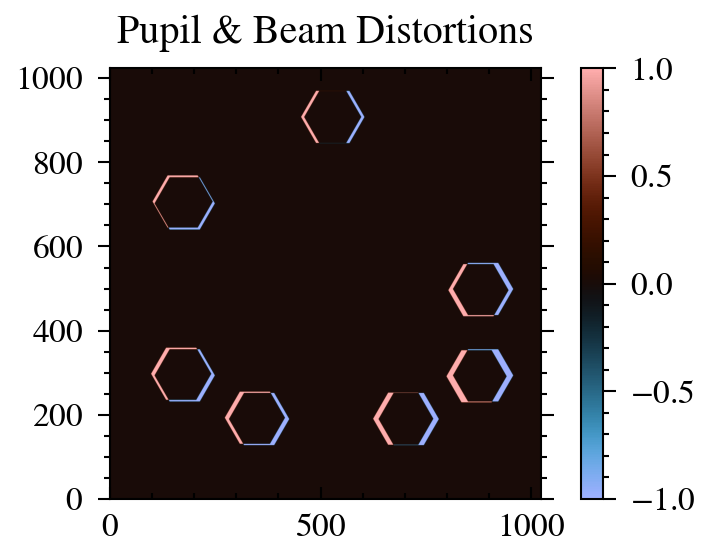

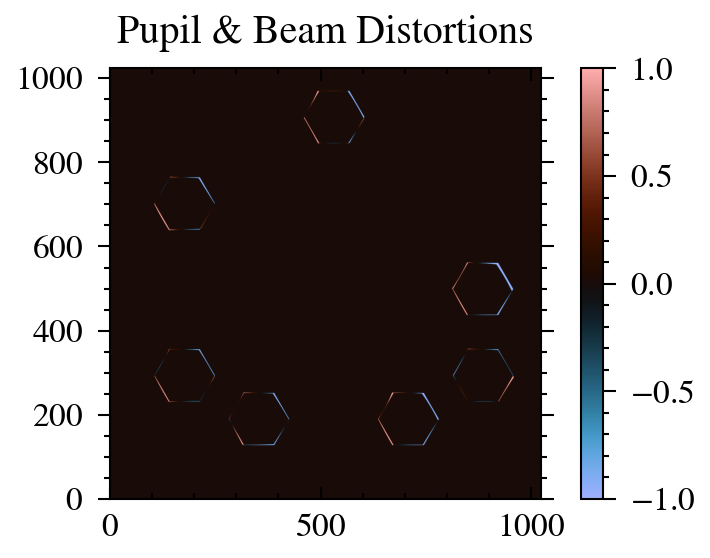

In [13]:
this_state = load_dict("/home/dgxuser/max/outputs/retrain/26-06-10_07-39-22_467698/final_state.npy")

this_dist = this_state["distortion"]
this_model = model.set("distortion", this_dist)
print(model.transformation.powers)
print(model.primary_powers)

plot_mask_diff(this_model.pupil_mask.calc_mask(optics.wf_npixels, optics.diameter))

this_pb = this_state["primary_beam"]
this_model = model.set("primary_beam", this_pb)
plot_mask_diff(this_model.pupil_mask.calc_mask(optics.wf_npixels, optics.diameter))


0 0


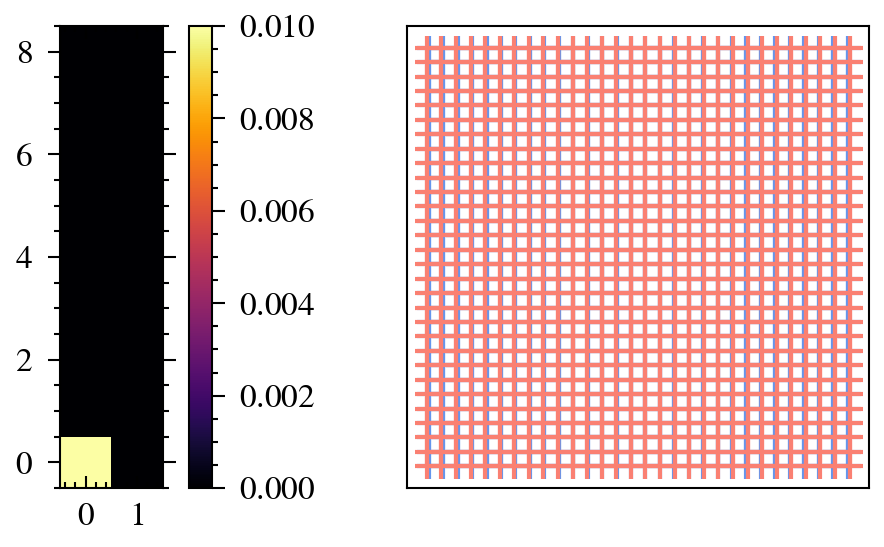

1 0


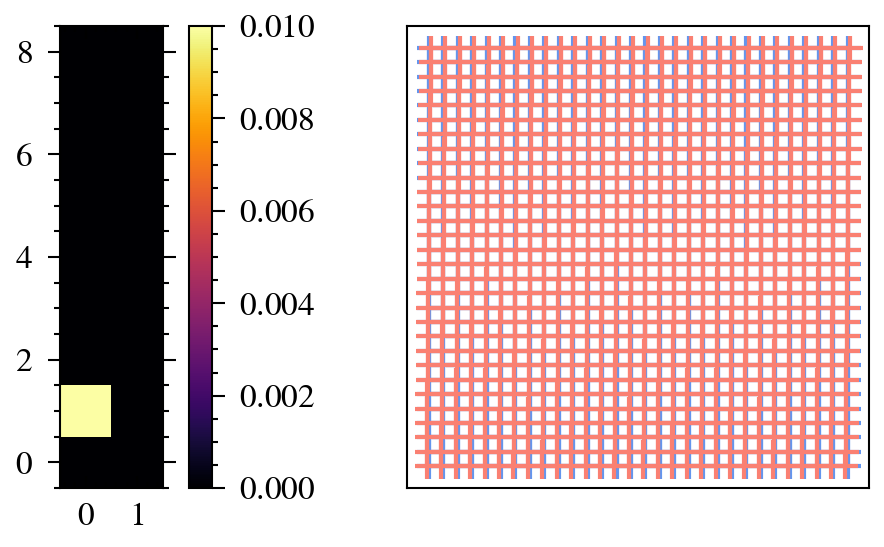

2 0


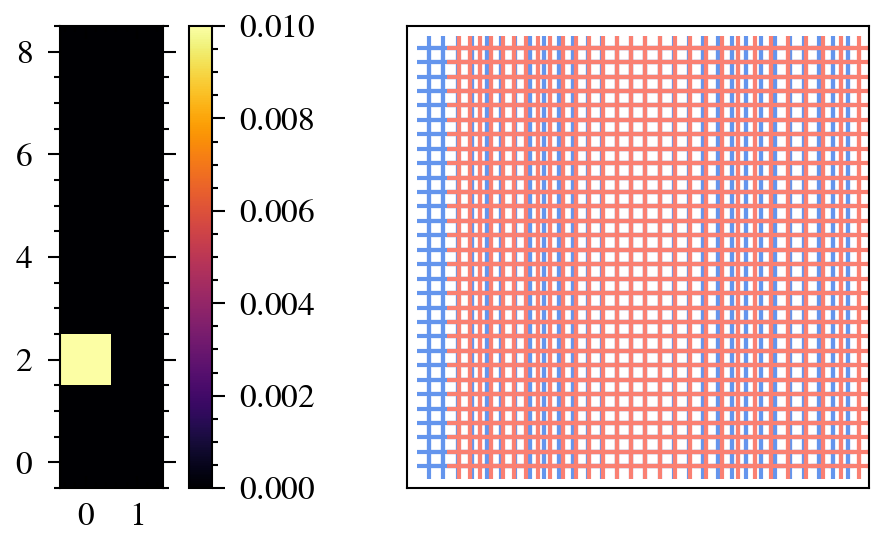

3 0


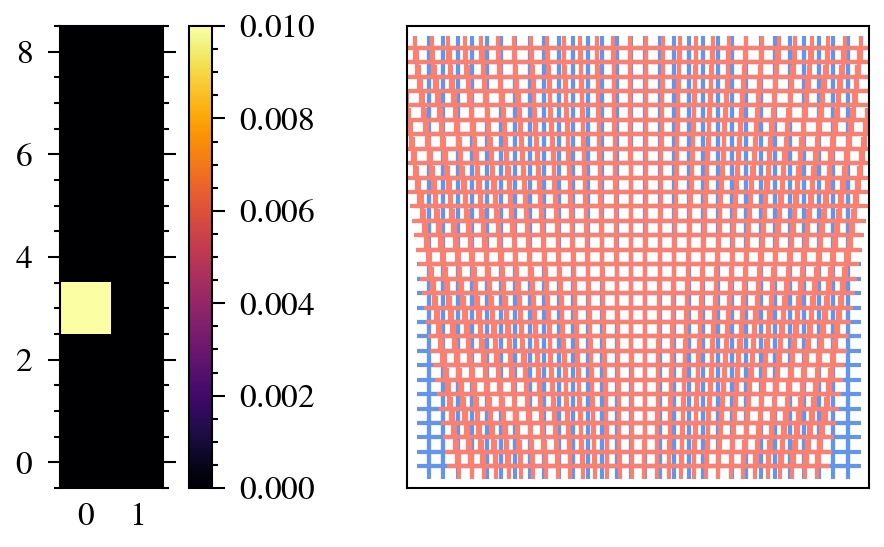

4 0


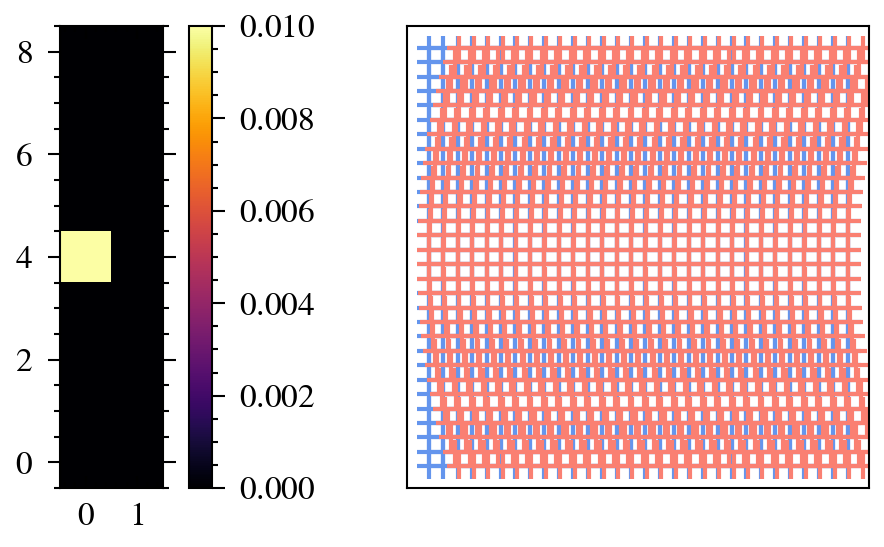

5 0


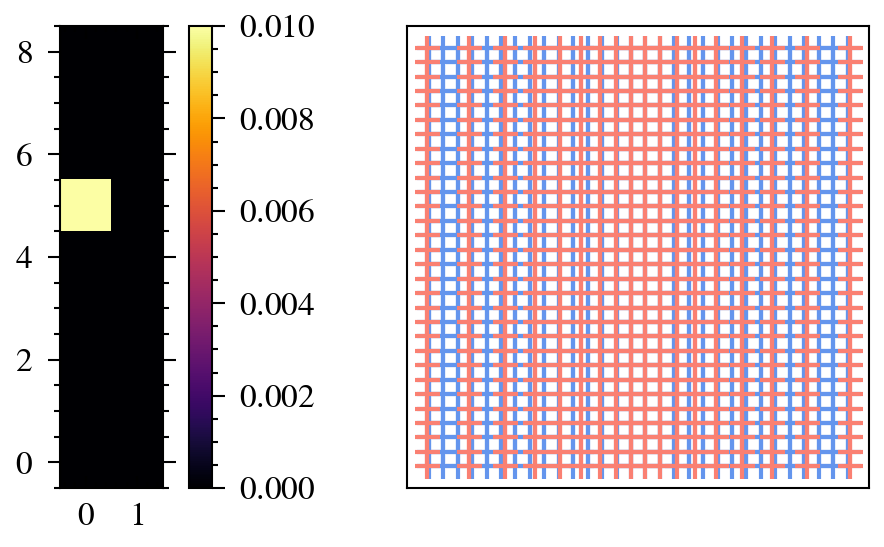

6 0


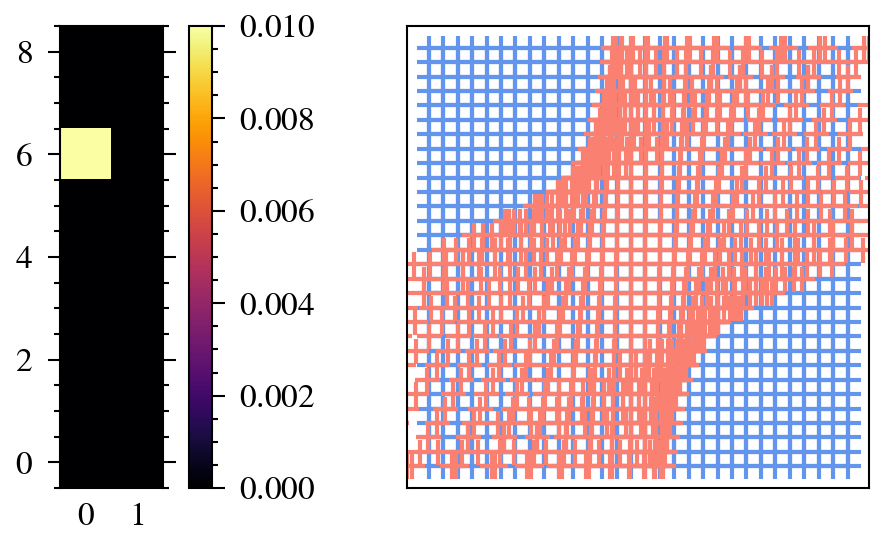

7 0


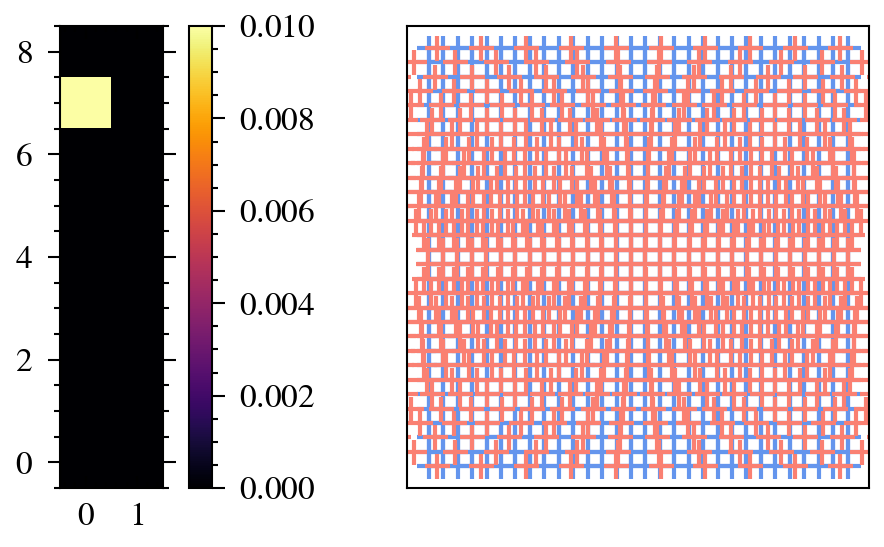

8 0


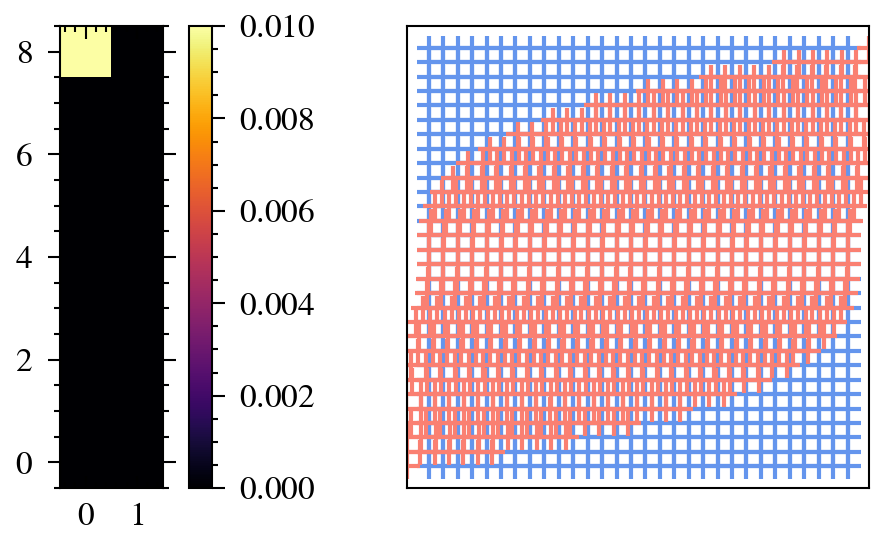

0 1


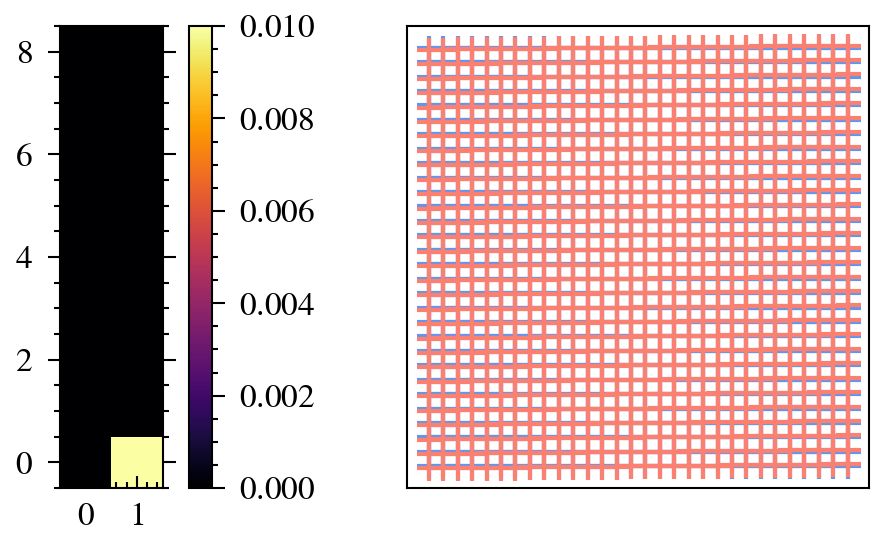

1 1


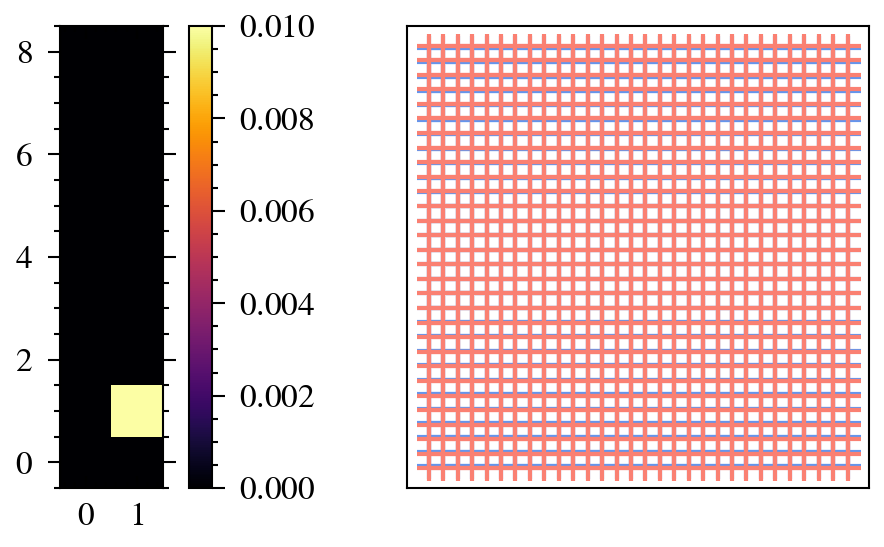

2 1


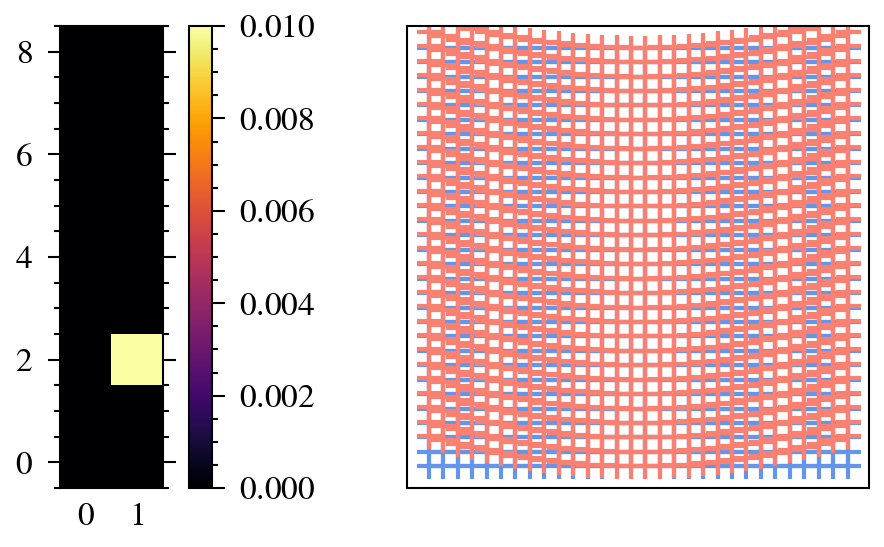

3 1


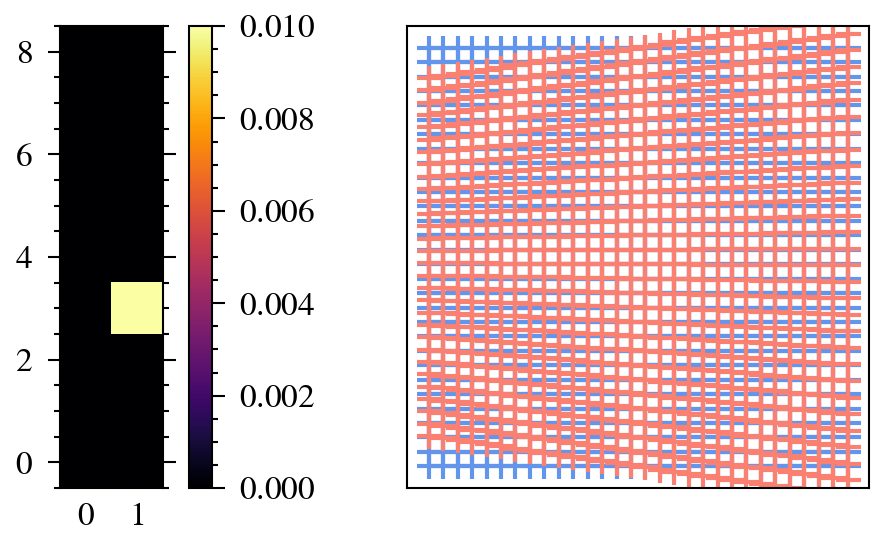

4 1


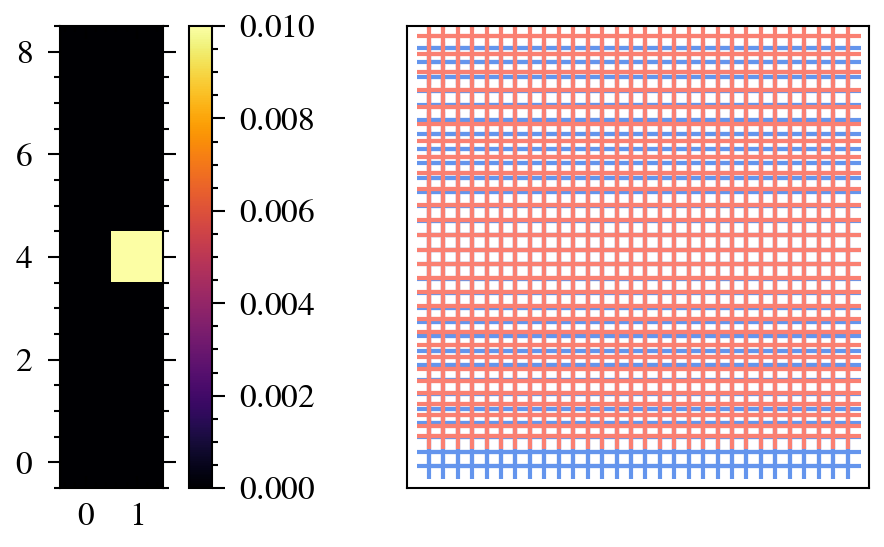

5 1


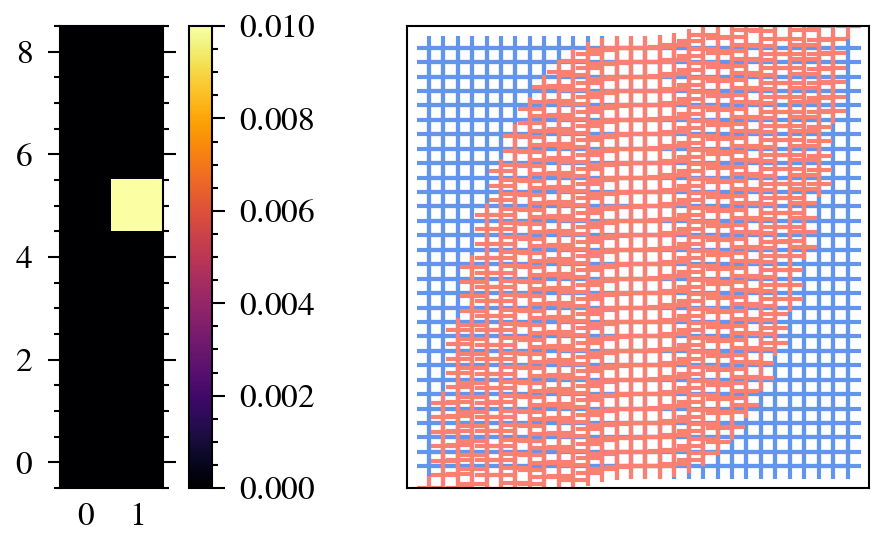

6 1


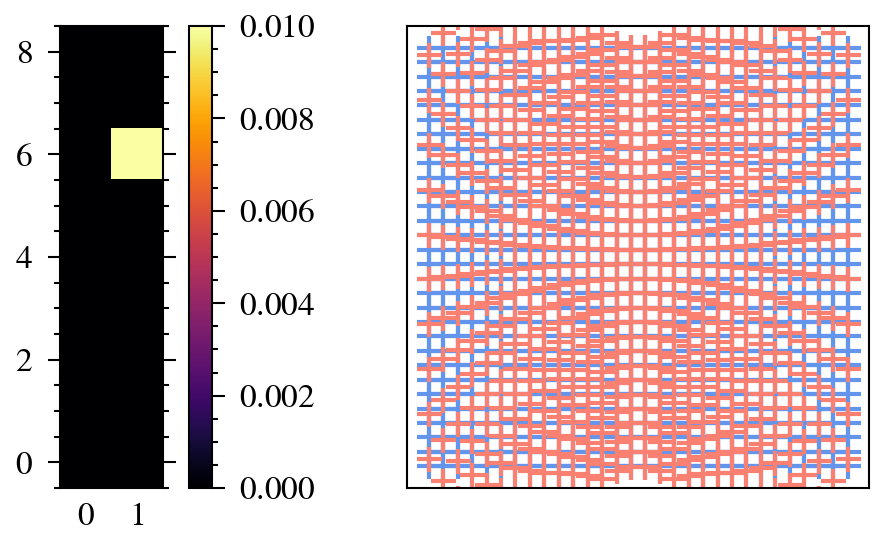

7 1


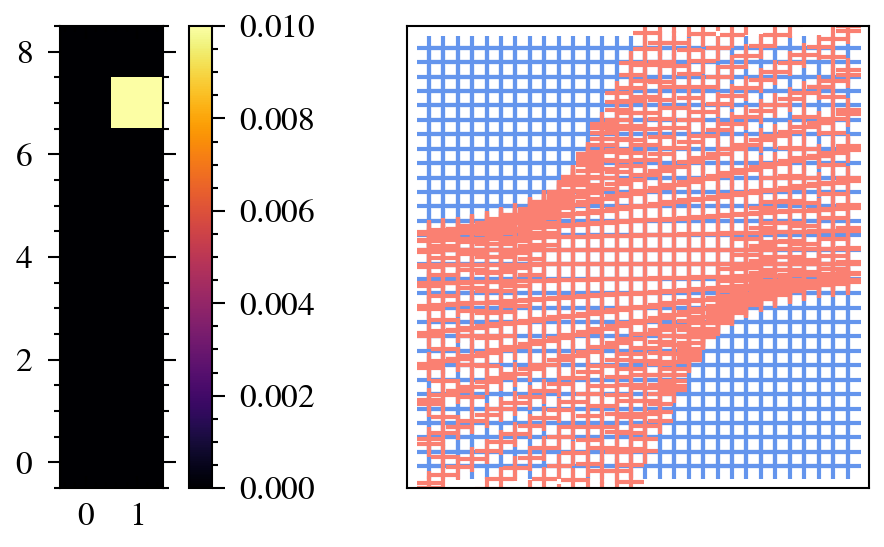

8 1


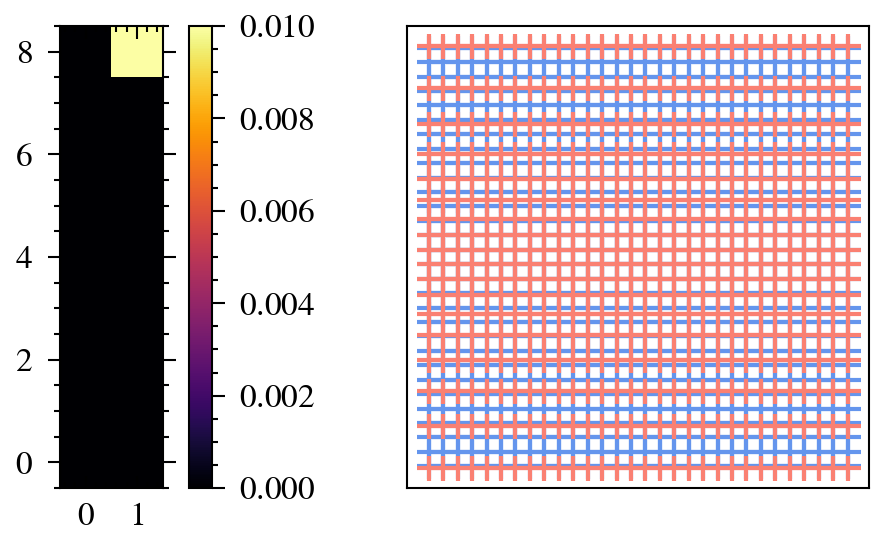

In [14]:
import dLux as dl
from dLux import utils as dlu

distortion = np.zeros_like(model.distortion)

for j in range(model.distortion.shape[0]):
    for i in range(model.distortion.shape[1]):
        print(i, j)

        this_dist = distortion.at[j, i].set(1e-2)
        coords = dlu.pixel_coords(30, pixel_scale=1.)
        transform = model.transformation
        transform = transform.set("distortion", this_dist)
                                  
        dist_coords = transform.apply(coords)
        
        fig, ax = plt.subplots(1, 2, figsize=(5, 2))
        
        im = ax[0].imshow(this_dist.T)
        fig.colorbar(im, ax=ax[0])
        
        ax[1].scatter(coords[0], coords[1], marker="+", color="cornflowerblue", alpha=1)
        ax[1].scatter(dist_coords[0], dist_coords[1], marker="+", color="salmon")
        ax[1].axis("square")
        ax[1].set(
            xlim=(-16, 16),
            ylim=(-16, 16),
            xticks=[],
            yticks=[],
        )
            
        # ax[1].grid()
        
        plt.show()

## Pupil and beam

In [15]:
# Perturbing distorted coordinates
optics = model.optics
null_pupil_mask = model.optics.pupil_mask.multiply("primary_beam", 0.0).multiply("distortion", 0.0)
null_mask = null_pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
def plot_mask_diff(mask):
    fig, ax = plt.subplots(figsize=(3, 2))
    
    ax.set_title("Pupil & Beam Distortions")
    im = ax.imshow(mask - null_mask, cmap="berlin", norm=mpl.colors.CenteredNorm())
    fig.colorbar(im, ax=ax)
    
    fig.tight_layout()
    plt.show()

0 0


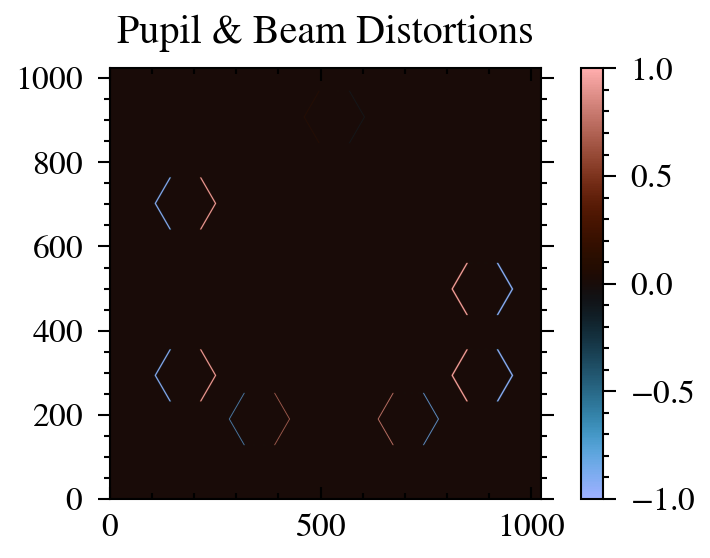

0 1


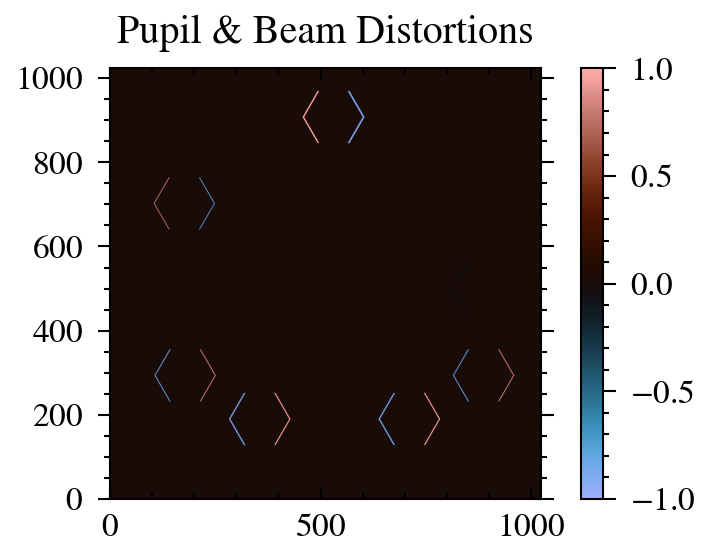

0 2


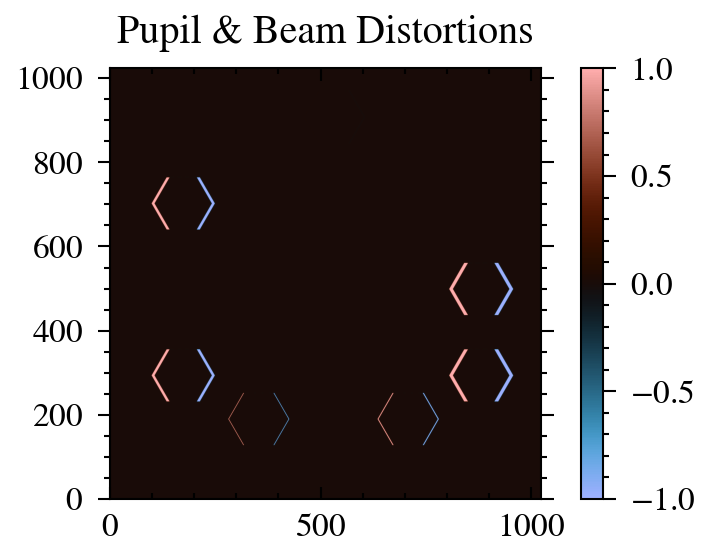

0 3


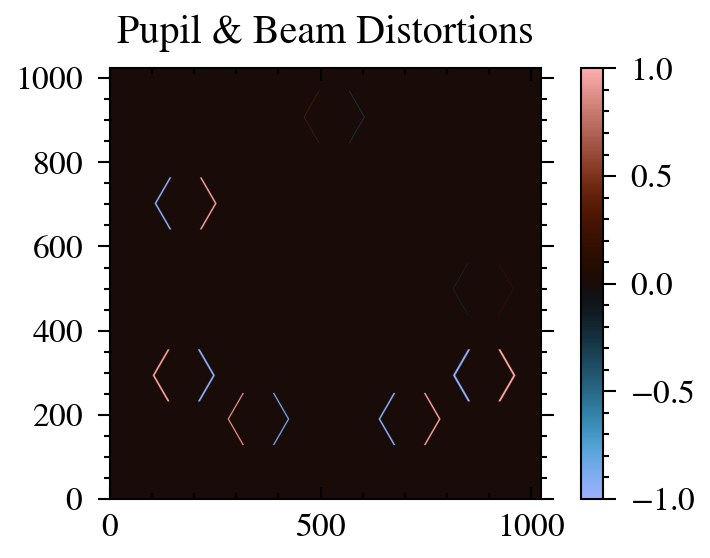

0 4


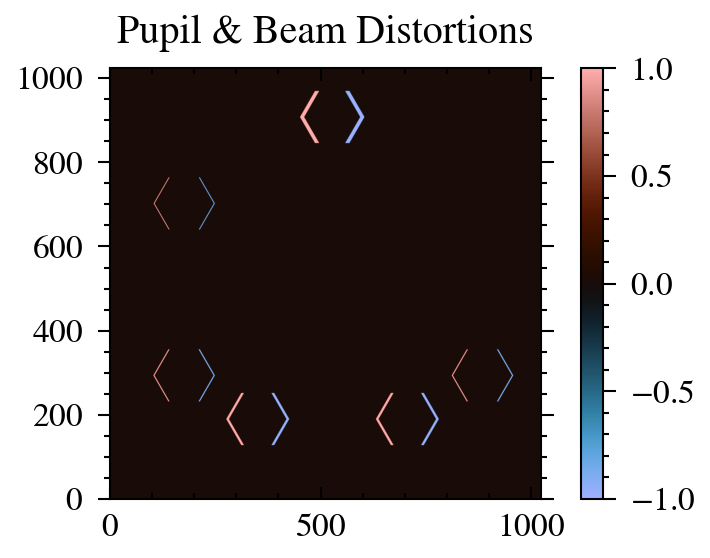

0 5


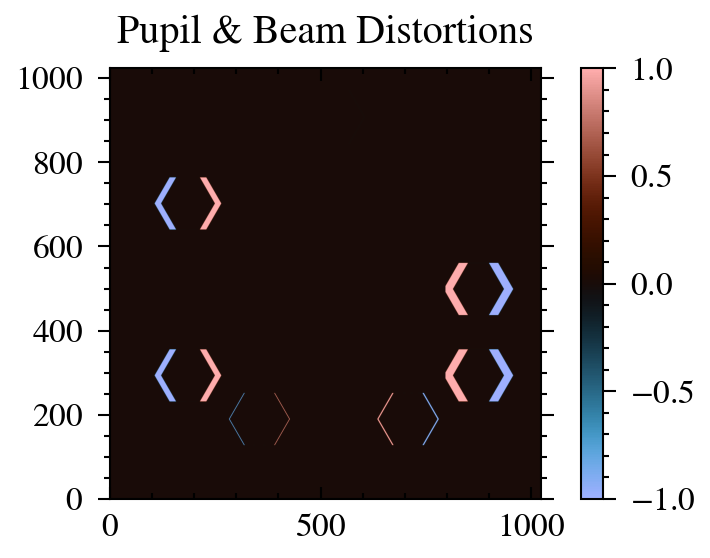

0 6


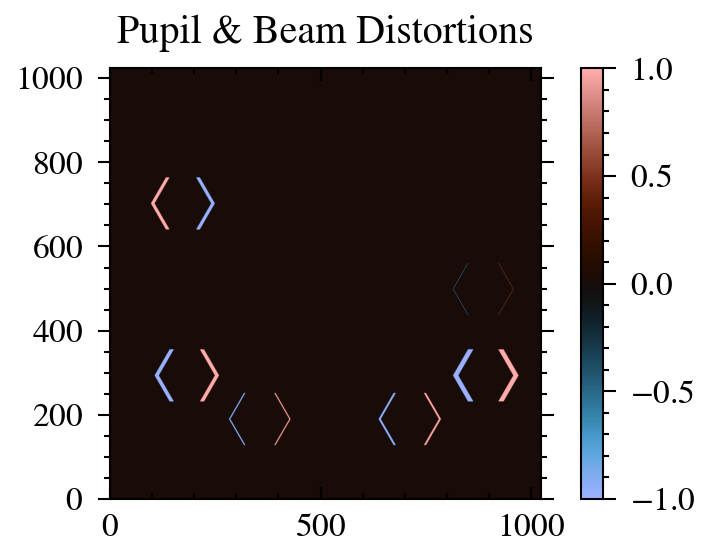

0 7


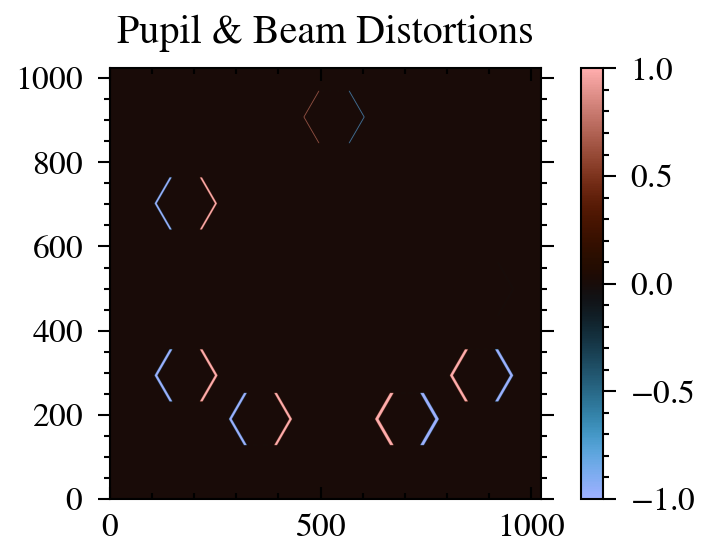

0 8


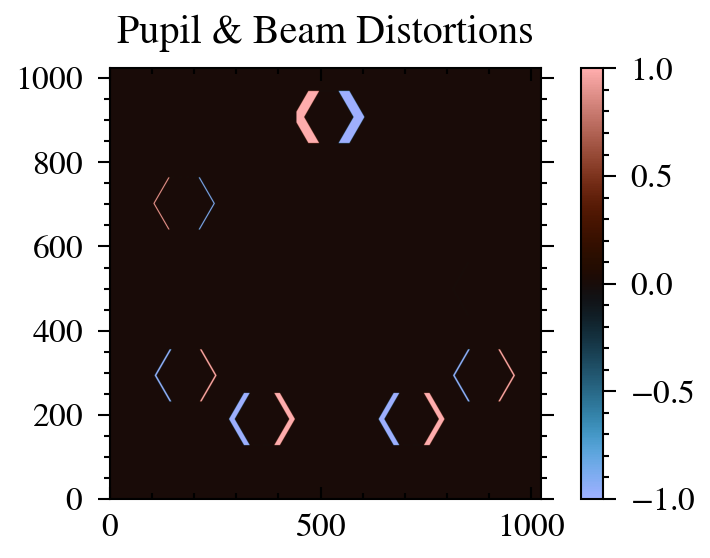

1 0


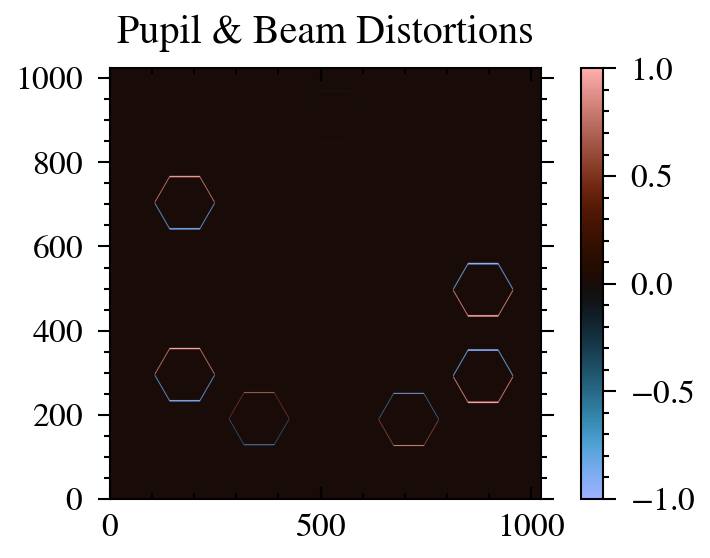

1 1


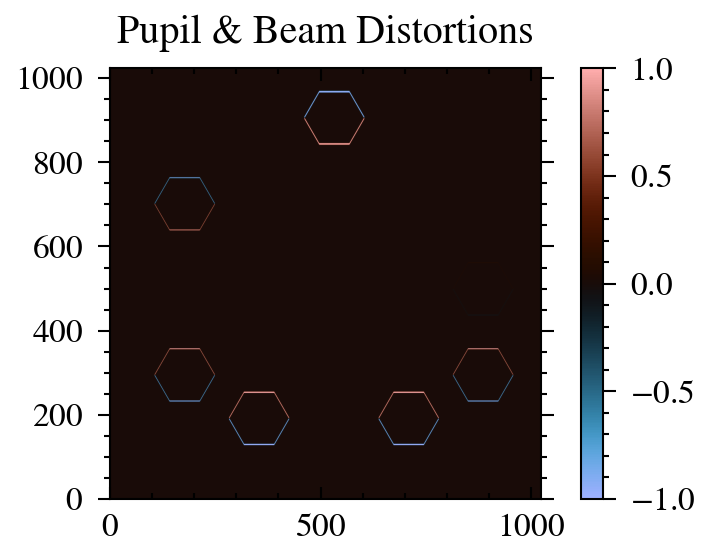

1 2


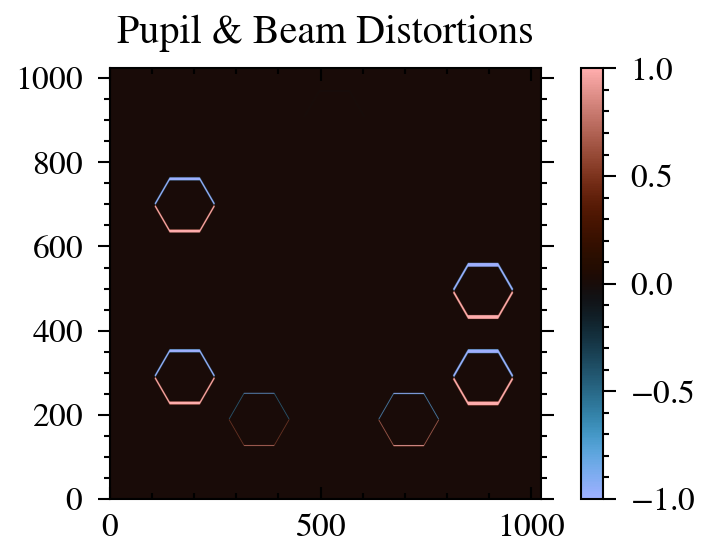

1 3


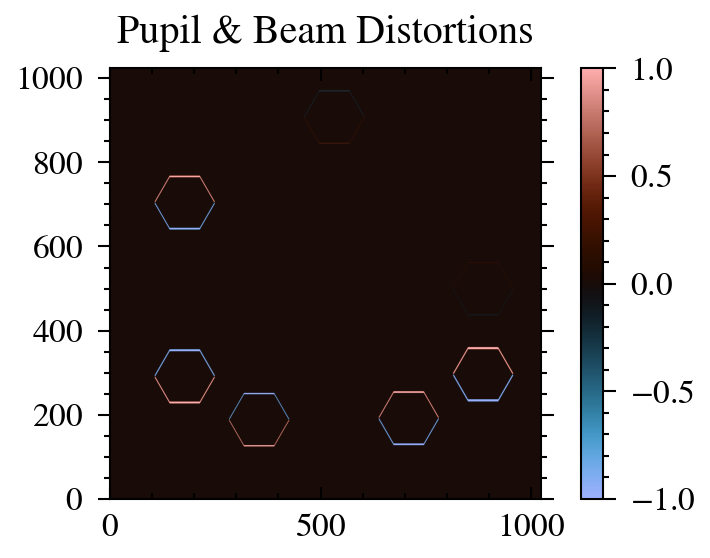

1 4


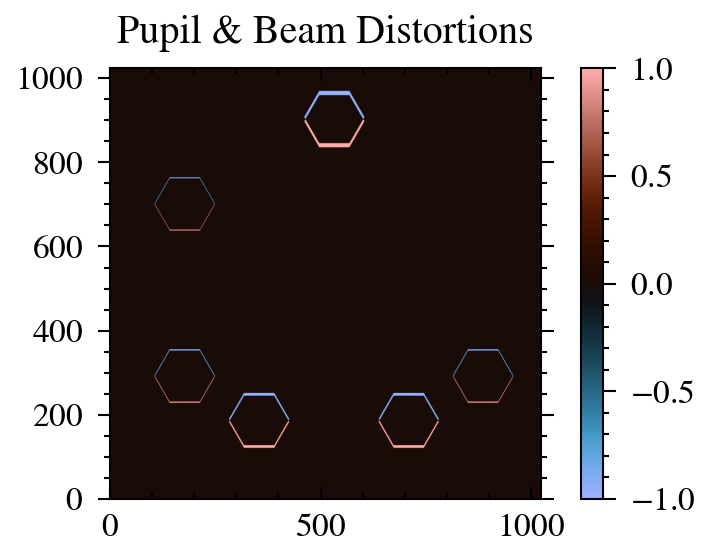

1 5


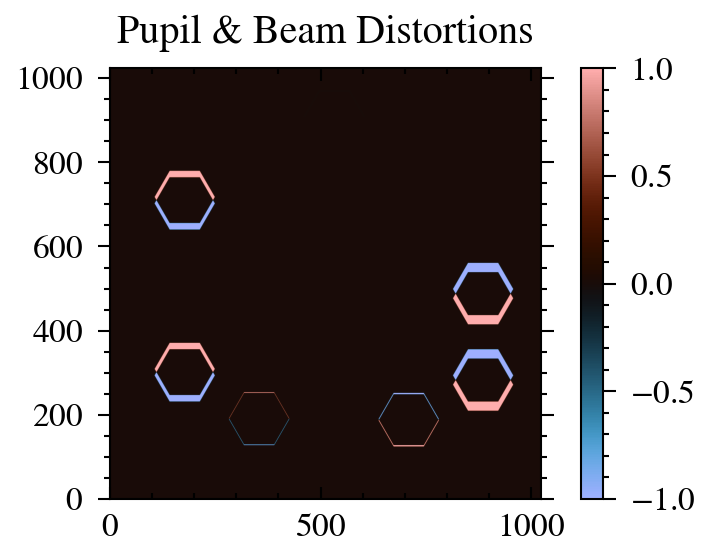

1 6


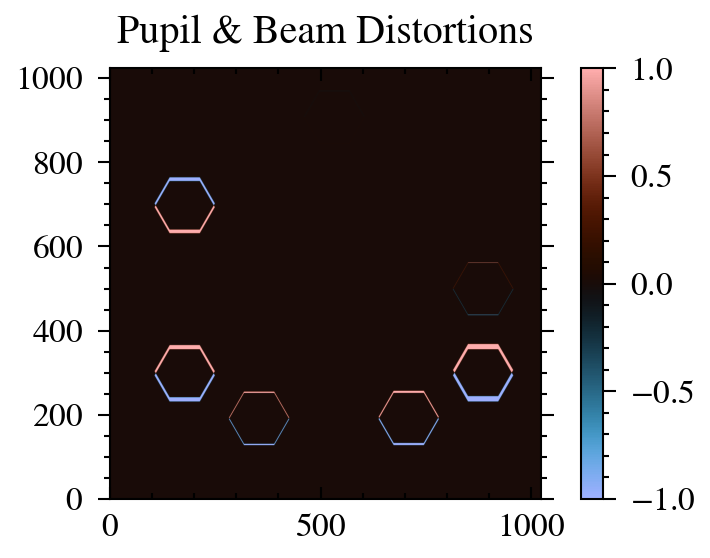

1 7


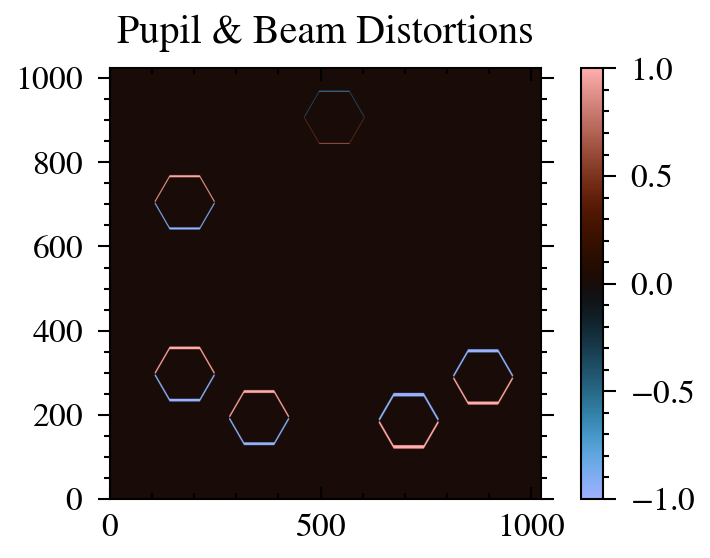

1 8


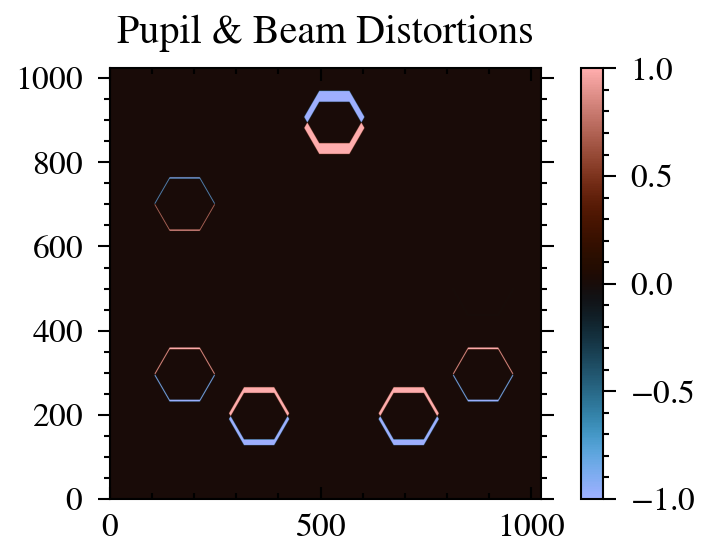

In [16]:

for i in range(model.distortion.shape[0]):
    for j in range(model.distortion.shape[1]):
        print(i, j)
        d = np.zeros_like(model.distortion)
        d = d.at[i, j].set(1e-2)
        
        pupil_mask = model.optics.pupil_mask.set("distortion", d)
        mask = pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
        
        plot_mask_diff(mask)


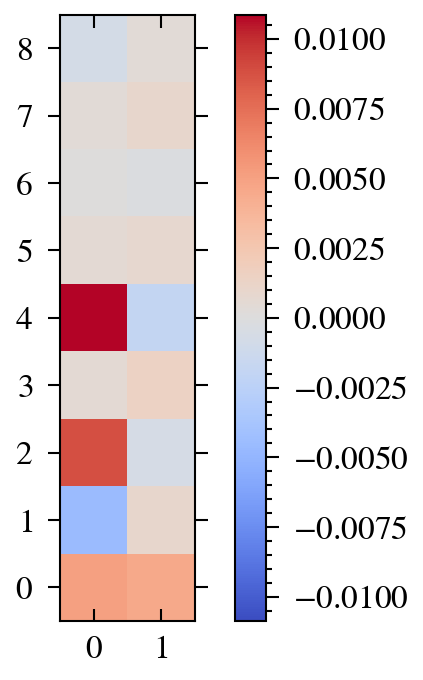

In [28]:
plt.imshow(this_dist.T, coolwarm, norm=mpl.colors.CenteredNorm())
plt.minorticks_off()
plt.colorbar()

0 0 0.005030613698989502


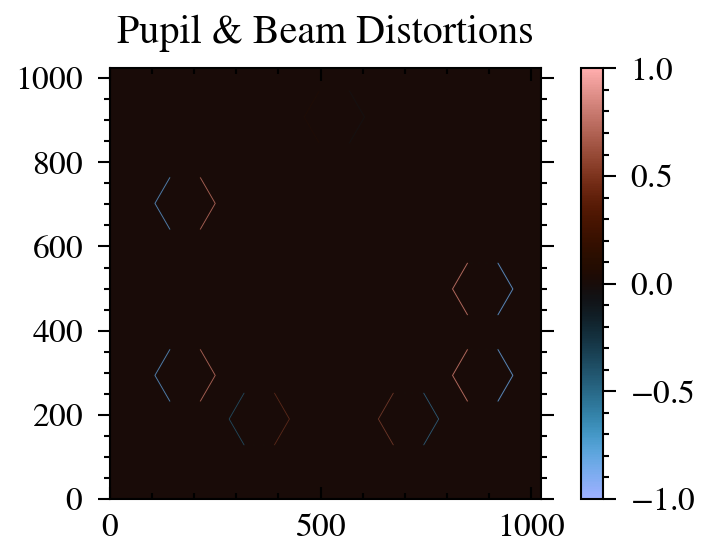

0 1 -0.004567399819176816


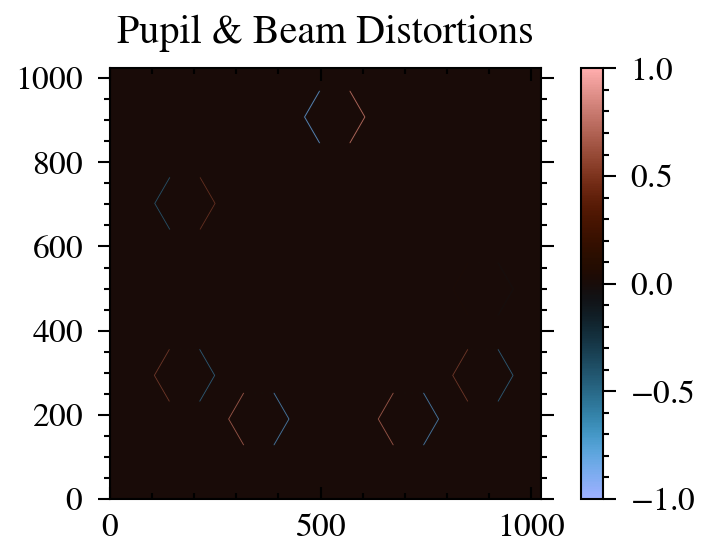

0 2 0.008825930072205994


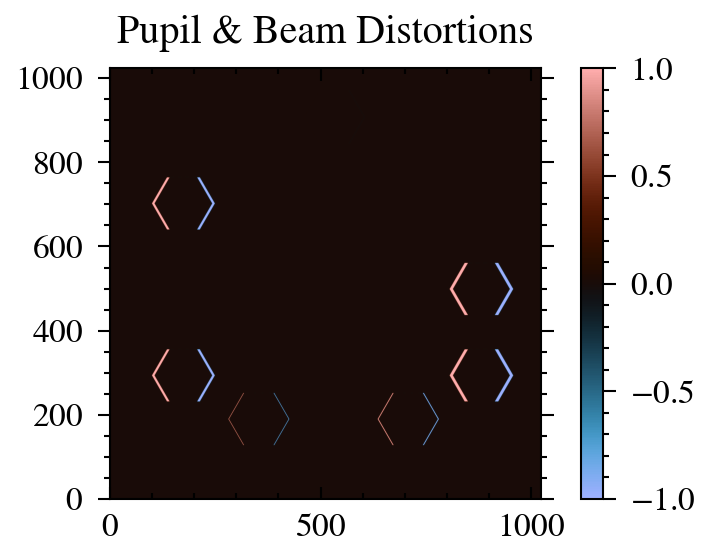

0 3 0.000587017247035629


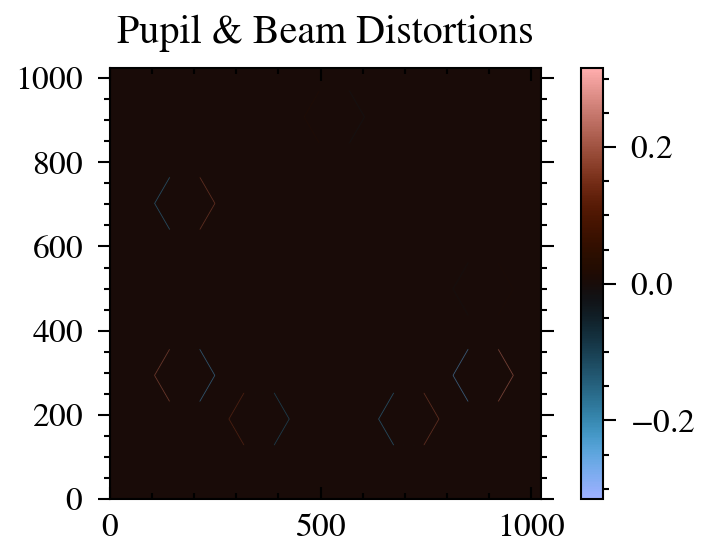

0 4 0.010871296744841719


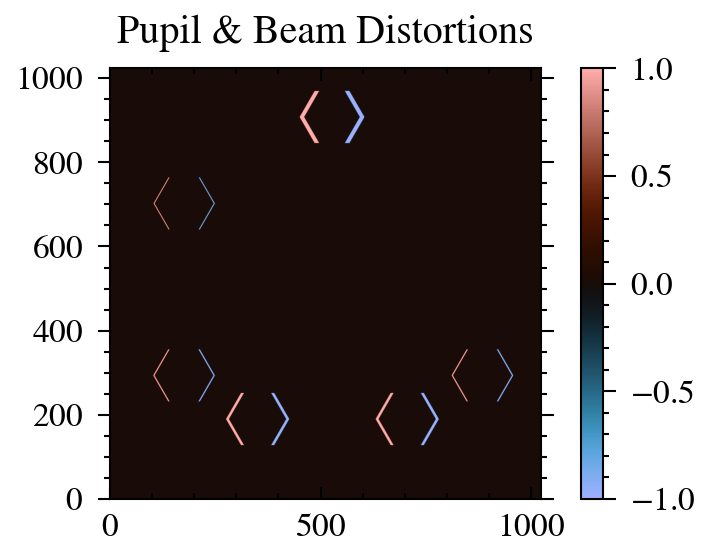

0 5 0.0005203044646837814


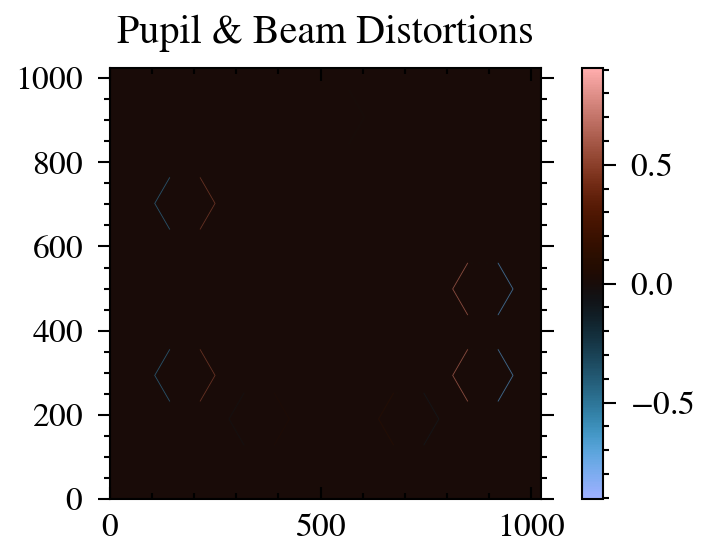

0 6 6.009907815011188e-05


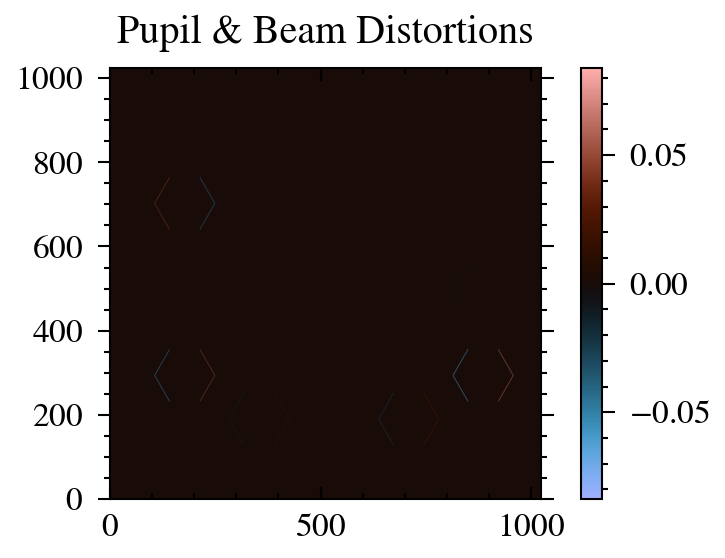

0 7 0.00040615154077869954


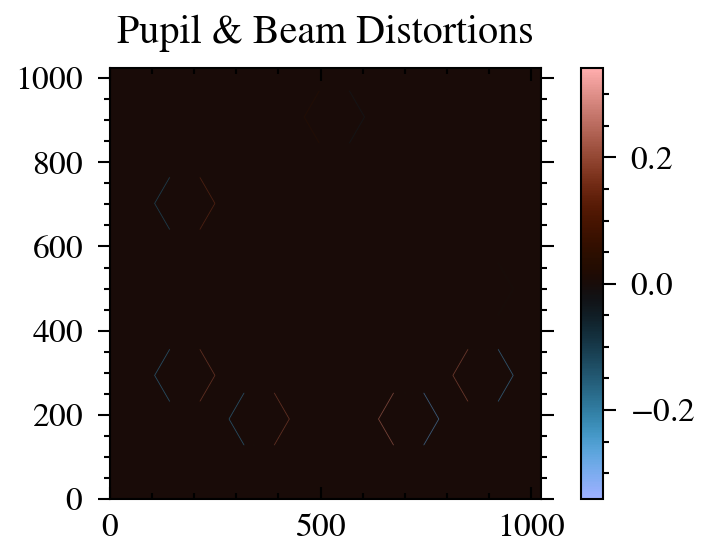

0 8 -0.000719002870628204


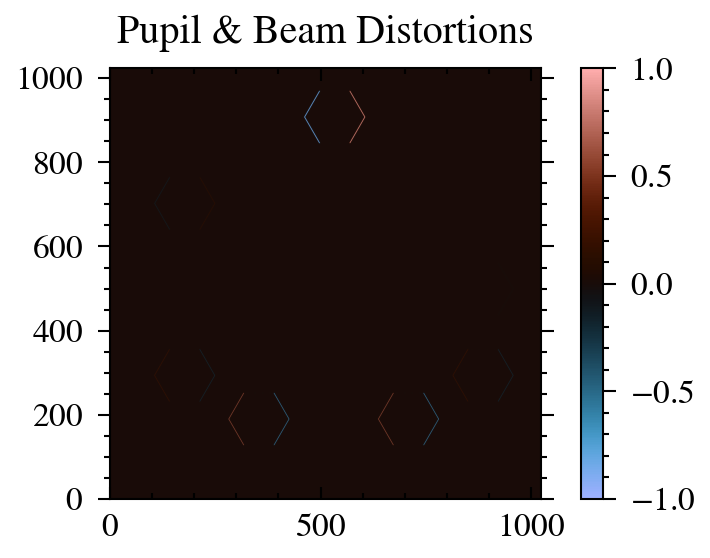

1 0 0.004577444459029613


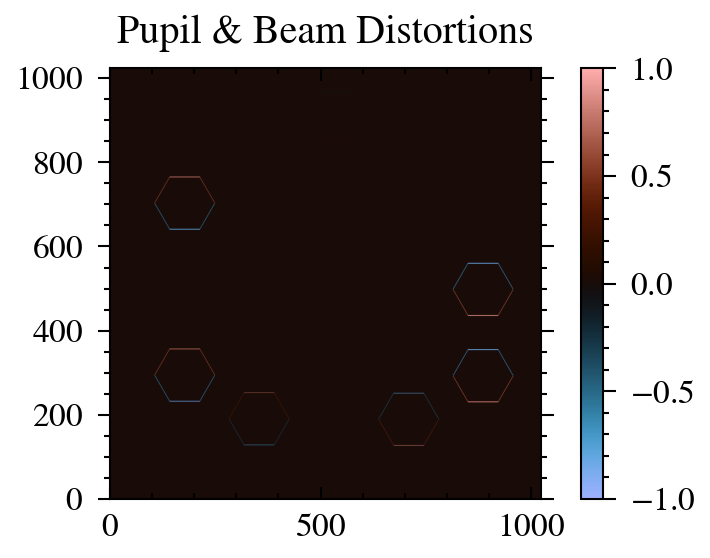

1 1 0.0009692887452890656


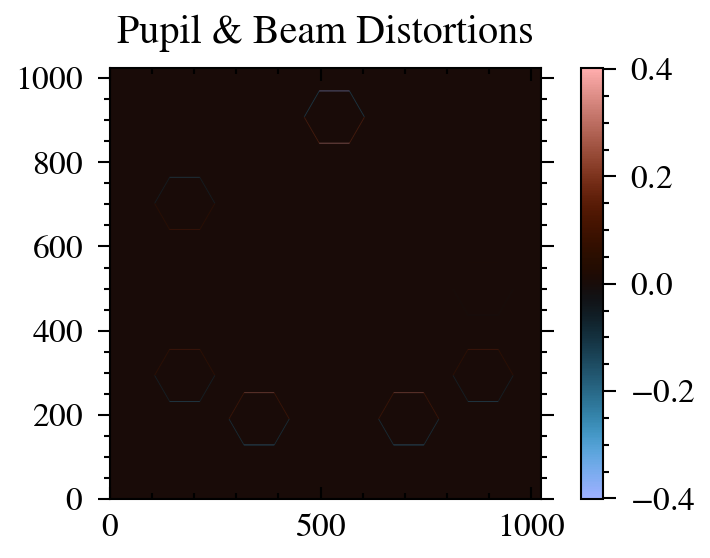

1 2 -0.0006305007787477197


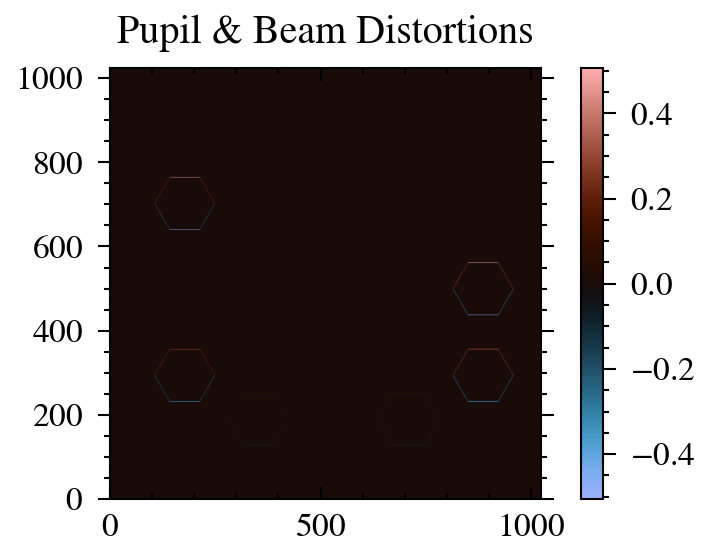

1 3 0.0014093256457223808


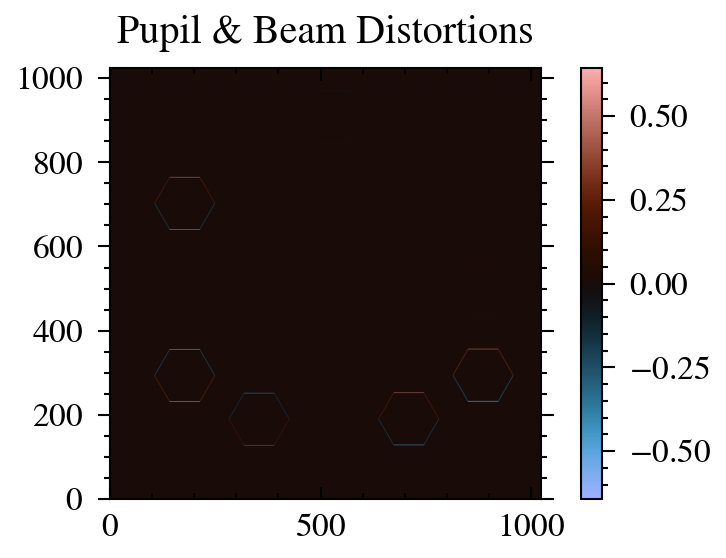

1 4 -0.0018816242509859982


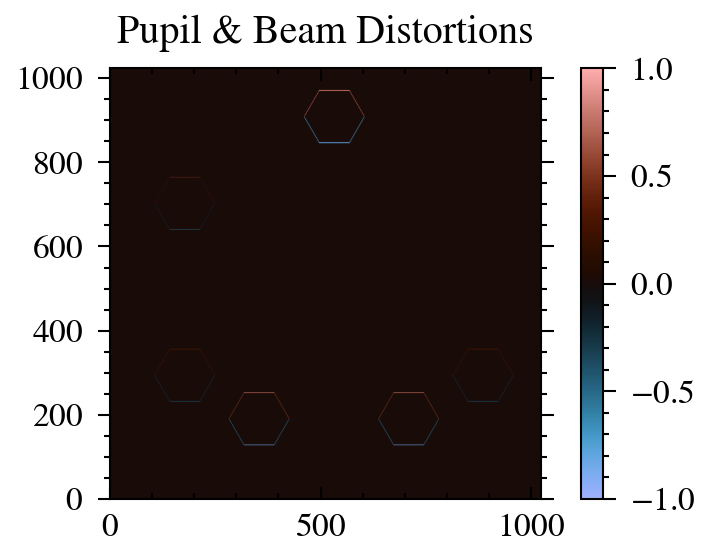

1 5 0.000771233373883415


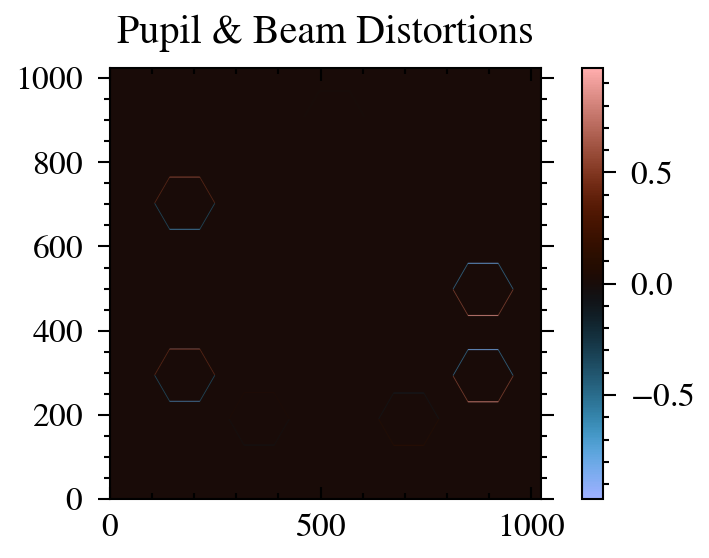

1 6 -0.0001882172469978511


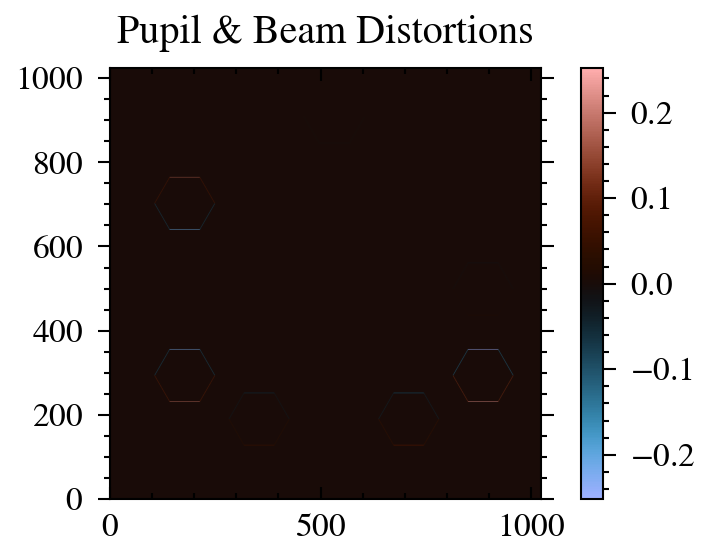

1 7 0.000959408243943622


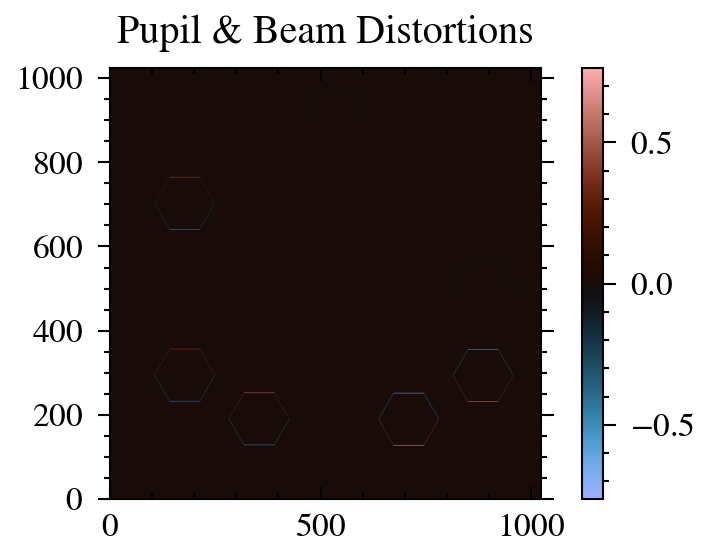

1 8 0.0003774863901783737


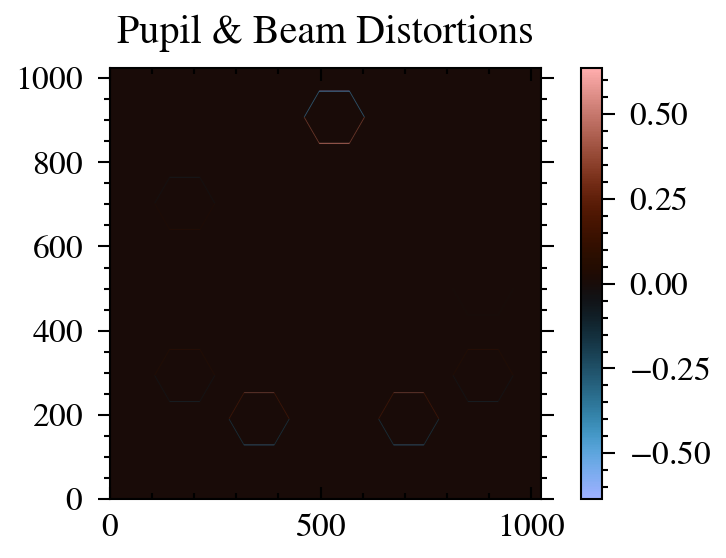

In [21]:
this_dist = this_state["distortion"]
this_model = model.set("distortion", this_dist)
this_model = this_model.set("primary_beam", np.zeros_like(this_state["primary_beam"]))

for i in range(this_model.distortion.shape[0]):
    for j in range(this_model.distortion.shape[1]):
        print(i, j, this_model.distortion[i, j])
        d = np.zeros_like(this_model.distortion)
        d = d.at[i, j].set(this_model.distortion[i, j])
        
        pupil_mask = this_model.optics.pupil_mask.set("distortion", d)
        mask = pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
        
        plot_mask_diff(mask)
